In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import xarray as xr
import numpy as np
from distributed import Client, LocalCluster
import dask
import pickle
import os
from scipy.stats import linregress
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import linregress
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, Matern, RationalQuadratic
import joblib # For saving our models
import time
import emcee
from matplotlib.ticker import FuncFormatter
import numpy as np
import pickle
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import string
plt.rcParams['text.usetex'] = True
import corner # The library for creating corner plots
np.random.seed(42)

# Loadings neaded for LaTex

In [11]:
# Get the current PATH
original_path = os.environ.get('PATH', '')
latex_path = '/glade/u/apps/casper/24.12/spack/opt/spack/texlive/20240312/gcc/12.4.0/nm7e/bin/x86_64-linux' 
# Prepend the LaTeX path to the system's PATH
# We prepend it to make sure it's found first.
os.environ['PATH'] = latex_path + os.pathsep + original_path
plt.rcParams['text.usetex'] = True

# Load regime & control dataframes

In [12]:
read_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_regime2 = pd.read_pickle(read_path+'df_regime2_perturbed_members.pkl')
df_cntl_regime2 = pd.read_pickle(read_path+'df_regime2_cntl.pkl')
df_cntl = pd.read_pickle(read_path+'df_all_regimes_cntl.pkl')
print(df_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl[['RESTOM_PD', 'LWP_PD_regime2', 'WROF_PD_regime2','PAF_PD_regime2']].T)

                  0          1          2           3          4          5   \
RESTOM_PD  22.767999  10.145342  17.262480   -6.977647  21.915214  21.711642   
LWP_PD      3.057743  37.931980  10.159395  147.974965   5.190044   4.751587   
WROF_PD     0.799337   0.885769   0.920615    0.054271   0.803136   0.778199   
PAF_PD      0.005089   0.004556   0.004543    0.063875   0.002875   0.003208   

                   6          7          8           9   ...         40  \
RESTOM_PD   -7.650290  19.457138  14.639741   -2.185409  ...  -1.116216   
LWP_PD     148.395507  13.462151  14.315497  110.949258  ...  86.064168   
WROF_PD      0.053720   0.941904   0.942558    0.342422  ...   0.520146   
PAF_PD       0.062392   0.010737   0.009245    0.015458  ...   0.008924   

                   41         42          43         44         45         46  \
RESTOM_PD   -7.637161  23.359594   -7.432411  16.070160  16.228917  19.658779   
LWP_PD     148.083371   4.195462  148.166729  15.888349  10.1

# Load Scaler and transforms files

In [13]:
# Load scalar and transforms
scaler_file = './emulators_production/global_x_scaler.joblib'
global_x_scaler = joblib.load(scaler_file)
transform_file = './emulators_production/production_transforms.joblib'
transforms = joblib.load(transform_file)

# Likelihood Functions used for MCMC runs

In [19]:
if False:
    def log_prior(theta):
        """Checks if the log-scaled parameters 'theta' are within [0, 1] inclusive."""
        #if np.all((theta >= 0) & (theta <= 1)):
        if np.all((theta > 0) & (theta < 1)):
            return 0.0    
        return -np.inf

if True:
    def log_prior(theta):
        """
        Strict rejection of samples outside 2^(-8) to 2^(+8).
        """
        # Define valid range
        # Bounds in regular space
        valid_lower_log = np.log10([2**-8., 2**-8.])  # Lower bounds in log10 space
        valid_upper_log = np.log10([2**8., 2**8.])    # Upper bounds in log10 space
        
        # Ensure the input is reshaped for the scaler (expecting 2D input: (n_samples, n_features))
        valid_lower_scaled = global_x_scaler.transform(valid_lower_log.reshape(1, -1))[0]  # Scaled lower bound
        valid_upper_scaled = global_x_scaler.transform(valid_upper_log.reshape(1, -1))[0]  # Scaled upper bound
            
        # Check if all dimensions of theta are within the valid range
        if np.all((theta >= valid_lower_scaled) & (theta <= valid_upper_scaled)):
            return 0.0  # Parameters are valid; flat prior
        return -np.inf  # Reject invalid parameters




def log_likelihood_independent(theta, emulators, transform_types, observations, obs_errors, include_emulator_uncertainty=False):
    """
    Calculates the log-likelihood for independent constraints. (Cleaned up for clarity)
    """
    theta_2d = np.atleast_2d(theta)
    total_log_like = 0.0
    try:
        for var_name, emulator in emulators.items():
            pred_val, pred_std = emulator.predict(theta_2d, return_std=True)
            pred_val, pred_std = pred_val[0], pred_std[0]

            transform_type = transform_types[var_name]
            obs_val = observations[var_name]
            obs_err = obs_errors[var_name]

            if not np.isfinite(pred_val): return -np.inf

            # Handle log-transformed observations
            if transform_type == 'log':
                obs_val = np.log(obs_val)

            # Calculate total error variance
            total_variance = obs_err**2
            if include_emulator_uncertainty:
                total_variance += pred_std**2

            total_log_like += -0.5 * ((pred_val - obs_val)**2 / total_variance)
        return total_log_like
    except Exception:
        return -np.inf

def log_likelihood_correlated(theta, emulators, transform_types, observations, errors, R_matrix, include_emulator_uncertainty=False):
    """
    Calculates log-likelihood using the HYBRID correlation matrix method.
    """
    theta_2d = np.atleast_2d(theta)
    try:
        var_names = list(emulators.keys())
        pred_vector = []
        pred_variances = [] # Emulator variances
        
        for var_name in var_names:
            pred_val, pred_std = emulators[var_name].predict(theta_2d, return_std=True)
            pred_vector.append(pred_val[0])
            if include_emulator_uncertainty:
                pred_variances.append(pred_std[0]**2)
            else:
                pred_variances.append(0.0)
        
        pred_vector = np.array(pred_vector)
        pred_variances = np.array(pred_variances)

        obs_vector = np.array([np.log(observations[v]) if transform_types[v] == 'log' else observations[v] for v in var_names])
        obs_errors = np.array([errors[v] for v in var_names])

        # --- Build the Hybrid Covariance Matrix dynamically ---
        # 1. Total standard deviations (D)
        total_stds = np.sqrt(obs_errors**2 + pred_variances)
        D_hybrid = np.diag(total_stds)

        # 2. Build Sigma = D * R * D
        Sigma_hybrid = D_hybrid @ R_matrix @ D_hybrid
        
        # 3. Invert for Mahalanobis distance
        inv_Sigma_hybrid = np.linalg.inv(Sigma_hybrid)
        
        residual_vector = pred_vector - obs_vector
        mahalanobis_sq = residual_vector @ inv_Sigma_hybrid @ residual_vector
        
        return -0.5 * mahalanobis_sq
    except (np.linalg.LinAlgError, ValueError): # Catch errors from bad matrices
        return -np.inf

def make_log_posterior_fn_multi_cov(emulators, transform_types, observations, errors,
                                    correlated_group=None, R_matrix=None, include_emulator_uncertainty=False):
    """
    Creates a posterior function supporting both independent and correlated constraints. (MODIFIED)
    """
    independent_emulators = {k: v for k, v in emulators.items() if correlated_group is None or k not in correlated_group['vars']}
    independent_obs = {k: v for k, v in observations.items() if correlated_group is None or k not in correlated_group['vars']}
    independent_errs = {k: v for k, v in errors.items() if correlated_group is None or k not in correlated_group['vars']}

    def log_posterior(theta):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        
        ll_independent = 0.0
        if independent_emulators:
            ll_independent = log_likelihood_independent(
                theta, independent_emulators, transform_types,
                independent_obs, independent_errs, include_emulator_uncertainty
            )

        ll_correlated = 0.0
        if correlated_group and R_matrix is not None:
            ll_correlated = log_likelihood_correlated(
                theta, correlated_group['emulators'], transform_types,
                correlated_group['obs'], correlated_group['errors'], R_matrix, include_emulator_uncertainty
            )
        
        return lp + ll_independent + ll_correlated
    return log_posterior

# Functions used for visualizing MCMC performance

In [18]:
def plot_trace(sampler, nwalkers, nsteps, ndim, exp_name):
    """Generate trace plots for each parameter across all steps."""
    samples = sampler.get_chain()  # Get full trace data (before flattening or thinning)
    invars = ['x_auto','x_accr']
    fig, axes = plt.subplots(ndim, figsize=(10, 6), sharex=True)
    Fontsize=14
    for i in range(ndim):
        for walker in range(nwalkers):
            axes[i].plot(samples[:, walker, i], alpha=0.1, lw=0.8,c='k')  # Trace for each walker
        #axes[i].set_title(invars[i]+' Trace Plot',Fontsize*1.5)
        axes[i].set_ylabel('Scaled '+invars[i],fontsize=Fontsize)
    axes[-1].set_xlabel("Steps",fontsize=Fontsize)
    axes[0].set_ylim(-0.05,1.05)
    axes[1].set_ylim(-0.05,1.05)
    
    plt.tight_layout()
    save_path = '/glade/u/home/mckenna/figures/'
    file_name = f'trace_plots_{exp_name}.png'
    #plt.savefig(save_path+file_name,dpi=300)
    plt.show()
    plt.close()


#### Step 2: Autocorrelation Times ####
def plot_autocorrelation(sampler):
    """Calculate and plot autocorrelation times."""
    try:
        tau = sampler.get_autocorr_time(quiet=True)  # Calculate autocorrelation times
        print("Autocorrelation Times:", tau)

        # Plot the autocorrelation values
        plt.figure(figsize=(10, 5))
        plt.plot(tau, marker='o', label="Autocorrelation Times for Each Parameter")
        plt.xlabel("Parameter Index")
        plt.ylabel("Autocorrelation Time")
        plt.title("Autocorrelation Times")
        plt.legend()
        plt.show()

    except Exception as e:
        print("Error calculating autocorrelation times. Ensure sufficient convergence/data.")
        print(f"Details: {e}")

def plot_trace_from_data(chain_data, log_prob_data, acceptance_fraction_data, exp_name):
    """
    Generate trace plots from saved MCMC data arrays.

    Args:
        chain_data (np.ndarray): The full MCMC chain. Shape: (nsteps, nwalkers, ndim).
        log_prob_data (np.ndarray): The log probability for each sample. Shape: (nsteps, nwalkers).
        acceptance_fraction_data (np.ndarray): The acceptance fraction for each walker. Shape: (nwalkers,).
        exp_name (str): The name of the experiment for titling and saving.
    """
    # --- 1. Extract Dimensions from the Input Data ---
    nsteps, nwalkers, ndim = chain_data.shape
    invars = ['x_auto', 'x_accr'] # Assuming ndim is always 2

    # --- 2. Create the Figure (Now with an extra row for log_prob) ---
    # We add 1 to ndim to make space for the log probability plot, which is a crucial diagnostic.
    fig, axes = plt.subplots(ndim + 1, figsize=(12, 8), sharex=True)
    Fontsize = 14

    # --- 3. Plot the Parameter Traces ---
    for i in range(ndim):
        ax = axes[i]
        for walker in range(nwalkers):
            ax.plot(chain_data[:, walker, i], alpha=0.1, lw=0.8, c='k')
        ax.set_ylabel(f'Scaled {invars[i]}', fontsize=Fontsize)
        # Set y-limits for scaled parameters, which should be between 0 and 1
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle='--', alpha=0.5)

    # --- 4. Plot the Log Probability Trace (Highly Recommended) ---
    ax = axes[ndim] # The last subplot
    for walker in range(nwalkers):
        ax.plot(log_prob_data[:, walker], alpha=0.1, lw=0.8, c='k')
    ax.set_ylabel("Log Probability", fontsize=Fontsize)
    ax.grid(True, linestyle='--', alpha=0.5)

    # --- 5. Final Formatting ---
    axes[-1].set_xlabel("Steps", fontsize=Fontsize)
    fig.suptitle(f'Trace Plot for Experiment: {exp_name}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust rect to make space for suptitle

    # Optional: Display acceptance fractions in the console
    print(f"\n--- Diagnostics for {exp_name} ---")
    print(f"Mean acceptance fraction: {np.mean(acceptance_fraction_data):.3f}")
    print(f"Std dev of acceptance fractions: {np.std(acceptance_fraction_data):.3f}")
    print(f"Min acceptance fraction: {np.min(acceptance_fraction_data):.3f}")
    print(f"Max acceptance fraction: {np.max(acceptance_fraction_data):.3f}")

    # --- 6. Save and Show ---
    save_path = '/glade/u/home/mckenna/figures/pnas_paper/'
    file_name = f'trace_plots_{exp_name}.png'
    # plt.savefig(save_path + file_name, dpi=300)
    plt.show()
    plt.close()

## Read in dense priors dictionary and convert to Dataframe
### Note: This assumes that emulator error is propagated into the dense prior

In [14]:
read_path='/glade/u/home/mckenna/work/'
with open(read_path+'dense_priors_dict.pkl', 'rb') as file:
    dense_priors = pickle.load(file)
df_dense_priors = pd.DataFrame.from_dict(dense_priors)

In [20]:
run_mcmc = True # Run MCMC or not?
run_prop = True # Propagate constrained inputs through output variables?
thin_bool = False # Thin MCMC?
include_emulator_uncertainty = True # Include emulator uncertainty in MCMC process?
use_correlations = True # Include variable covariance?

# Run MCMC one at a time

--- Calculating Correlation Matrix for: ['OLR_UPWELL_PD', 'OSR_UPWELL_PD'] ---
Correlation Matrix (R) to be used:
 [[ 1.         -0.98770099]
 [-0.98770099  1.        ]]

--- Preparing for MCMC Experiment: Radiation_Only_VarCov ---
  - Constraint: OLR_UPWELL_PD, Obs=241.03, Err=2.00
  - Constraint: OSR_UPWELL_PD, Obs=97.90, Err=2.00

--- Running MCMC for experiment: Radiation_Only_VarCov ---


100%|██████████| 5000/5000 [03:26<00:00, 24.17it/s]



--- MCMC Run Complete! ---


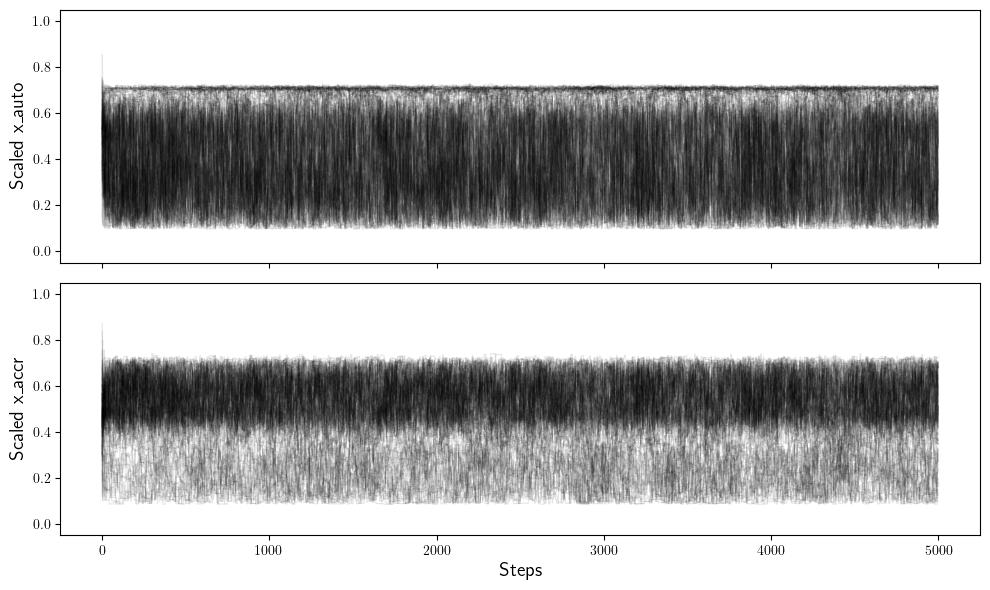

In [9]:
obs_error_fraction = 0.2


rad_vars = ['OLR_UPWELL_PD','OSR_UPWELL_PD']
cloud_vars = ['LWP_PD']
proc_vars = ['AUTOCONV_PD','ACCRETN_PD']
prox_vars = ['PRECL_PD','WROF_PD','PAF_PD']

experiment_name_base = 'Radiation_Only'
#experiment_name_base = 'Radiation_Plus_LWP'
#experiment_name_base = 'Radiation_Plus_LWP_ProcessRates'
#experiment_name_base = 'Radiation_Plus_LWP_PRECL'
#experiment_name_base = 'Radiation_Plus_LWP_ProxyRates'


if experiment_name_base == 'Radiation_Only':
    constraint_vars = rad_vars
elif experiment_name_base == 'Radiation_Plus_LWP':
    constraint_vars = rad_vars + cloud_vars
elif experiment_name_base == 'Radiation_Plus_LWP_ProcessRates':
    constraint_vars = rad_vars + cloud_vars + proc_vars
elif experiment_name_base == 'Radiation_Plus_LWP_ProxyRates':
    constraint_vars = rad_vars + cloud_vars + prox_vars
elif experiment_name_base == 'Radiation_Plus_LWP_PRECL':
    constraint_vars = rad_vars + cloud_vars + ['PRECL_PD']


if experiment_name_base != 'Radiation_Only':
    experiment_name = experiment_name_base+'_'+str(int(obs_error_fraction*100.))+'PercErr'
else:
    experiment_name = experiment_name_base

if use_correlations:
    experiment_name = experiment_name+'_VarCov'
else:
    experiment_name = experiment_name+'_NoVarCov'

variables_for_cov = constraint_vars # NOTE!: If we don't want variables to Co-Vary, then this needs to be changed to separate out variables used only for correlation vs. all constraint vars

if run_mcmc:
    emulators_dir = f'./emulators_production'
    
    # --- 1. Compute the CORRELATION Matrix (R) for the correlated group ---
    R = None # Initialize R as None
    if variables_for_cov:
        print(f"--- Calculating Correlation Matrix for: {variables_for_cov} ---")
        outputs_train = df_dense_priors[variables_for_cov].to_numpy()
        R = np.corrcoef(outputs_train, rowvar=False)

        if not use_correlations:
            print(">>> 'use_correlations' is False. Forcing independent calculation with identity matrix. <<<")
            R = np.identity(R.shape[0])
        
    print("Correlation Matrix (R) to be used:\n", R)

    # --- 2. Load Emulators and Prepare All Observations ---
    emulators_to_use = {}
    transformations_to_use = {}
    observations_to_use = {}
    errors_to_use = {}
    print(f"\n--- Preparing for MCMC Experiment: {experiment_name} ---")
    for var_name in constraint_vars:
        emulators_to_use[var_name] = joblib.load(f'./{emulators_dir}/gp_production_{var_name}.joblib')
        transformations = joblib.load(f'{emulators_dir}/production_transforms.joblib')
        transformations_to_use[var_name] = transformations[var_name]
        
        if var_name in rad_vars:
            obs_value = df_cntl[var_name].iloc[0]
        else: # Assumes all non-radiation vars are cloud vars
            obs_value = df_cntl[var_name+'_regime2'].iloc[0]
        observations_to_use[var_name] = obs_value
        

        if var_name == 'OLR_UPWELL_PD':
            errors_to_use[var_name] = 2.
        elif var_name == 'OSR_UPWELL_PD':
            errors_to_use[var_name] = 2.
        else:
            if transformations_to_use[var_name] == 'log':
                errors_to_use[var_name] = obs_error_fraction
            else:
                errors_to_use[var_name] = obs_error_fraction * abs(obs_value)
        if transformations_to_use[var_name] != 'log':     
            print(f"  - Constraint: {var_name}, Obs={obs_value:.2f}, Err={errors_to_use[var_name]:.2f}")
        else:
            print(f"  - Constraint: {var_name}, Obs={np.log(obs_value):.2f}, Err={errors_to_use[var_name]:.2f}")


    # --- 3. Structure Data for Correlated Group ---
    correlated_group_data = None
    if variables_for_cov:
        correlated_group_data = {
            'vars': variables_for_cov,
            'emulators': {var: emulators_to_use[var] for var in variables_for_cov},
            'obs': {var: observations_to_use[var] for var in variables_for_cov},
            'errors': {var: errors_to_use[var] for var in variables_for_cov}
        }


    log_posterior_fn = make_log_posterior_fn_multi_cov(
        emulators=emulators_to_use,
        transform_types=transformations_to_use,
        observations=observations_to_use,
        errors=errors_to_use,
        correlated_group=correlated_group_data,
        R_matrix=R, # Pass the correlation matrix R (will be None if no correlated vars)
        include_emulator_uncertainty=include_emulator_uncertainty
    )
    
    # --- 5. Run the MCMC Sampler ---
    ndim = 2
    nwalkers = 100
    nsteps = 5000
    burn_in = int(0.2 * nsteps)
    thin = 15 if thin_bool else 1


    # Bounds in regular space
    valid_lower_log = np.log10([2**-8., 2**-8.])  # Lower bounds in log10 space
    valid_upper_log = np.log10([2**8., 2**8.])    # Upper bounds in log10 space
    
    # Ensure the input is reshaped for the scaler (expecting 2D input: (n_samples, n_features))
    valid_lower_scaled = global_x_scaler.transform(valid_lower_log.reshape(1, -1))[0]  # Scaled lower bound
    valid_upper_scaled = global_x_scaler.transform(valid_upper_log.reshape(1, -1))[0]  # Scaled upper bound
    
    # Set mean and standard deviation for the normal distribution
    mean = (valid_lower_scaled + valid_upper_scaled) / 2  # Center of the bounds
    std_dev = np.abs(valid_upper_scaled - valid_lower_scaled) / 6  # Spread (approx 99.7%)
    
    # Generate samples and clip them to stay within bounds
    initial_state = np.random.normal(loc=mean, scale=std_dev, size=(nwalkers, ndim))    
    #initial_state = np.random.rand(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_fn, moves=emcee.moves.StretchMove(3.0))
    print(f"\n--- Running MCMC for experiment: {experiment_name} ---")
    sampler.run_mcmc(initial_state, nsteps, progress=True)
    print("\n--- MCMC Run Complete! ---")

    # Assuming plot_trace is defined elsewhere
    plot_trace(sampler, nwalkers, nsteps, ndim, experiment_name)

    if False:
        # --- 6. Save and Plot Results ---
        chain_flat = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
        chain_full = sampler.get_chain()
        output_filename = f'posterior_chain_{experiment_name}_{"thin" if thin_bool else "nothin"}_flat.npy'
        np.save('./mcmc_chains/' + output_filename, chain_flat)
        output_filename_full = f'posterior_chain_{experiment_name}_{"thin" if thin_bool else "nothin"}_full.npy'
        np.save('./mcmc_chains/' + output_filename_full, chain_full)
    
        # Save the data required for the Trace Plot
        log_prob_full = sampler.get_log_prob()
        acceptance_fractions = sampler.acceptance_fraction
        trace_data_filename = f'trace_data_{experiment_name}.npz'
        np.savez_compressed('./mcmc_chains/'+trace_data_filename,
                            chain=chain_full,
                            log_prob=log_prob_full,
                            acceptance_fraction=acceptance_fractions)

        print(f"Posterior chains saved to '{output_filename}' and '{output_filename_full}' ")
    


# Loop through MCMC experments (sans Radiation_Only)

Radiation_Plus_LWP_PRECL_WROF
--- Calculating Correlation Matrix for: ['OLR_UPWELL_PD', 'OSR_UPWELL_PD', 'LWP_PD', 'PRECL_PD', 'WROF_PD'] ---
Correlation Matrix (R) to be used:
 [[ 1.         -0.98770099 -0.90228268  0.522994    0.74351496]
 [-0.98770099  1.          0.94932811 -0.61873247 -0.82941388]
 [-0.90228268  0.94932811  1.         -0.68645523 -0.94339278]
 [ 0.522994   -0.61873247 -0.68645523  1.          0.7999927 ]
 [ 0.74351496 -0.82941388 -0.94339278  0.7999927   1.        ]]

--- Preparing for MCMC Experiment: Radiation_Plus_LWP_PRECL_WROF_5PercErr_VarCov ---
  - Constraint: OLR_UPWELL_PD, Obs=241.03, Err=2.00
  - Constraint: OSR_UPWELL_PD, Obs=97.90, Err=2.00
  - Constraint: LWP_PD, Obs=78.19, Err=3.91
  - Constraint: PRECL_PD, Obs=0.01, Err=0.00
  - Constraint: WROF_PD, Obs=0.62, Err=0.03

--- Running MCMC for experiment: Radiation_Plus_LWP_PRECL_WROF_5PercErr_VarCov ---


100%|██████████| 5000/5000 [06:25<00:00, 12.97it/s]



--- MCMC Run Complete! ---


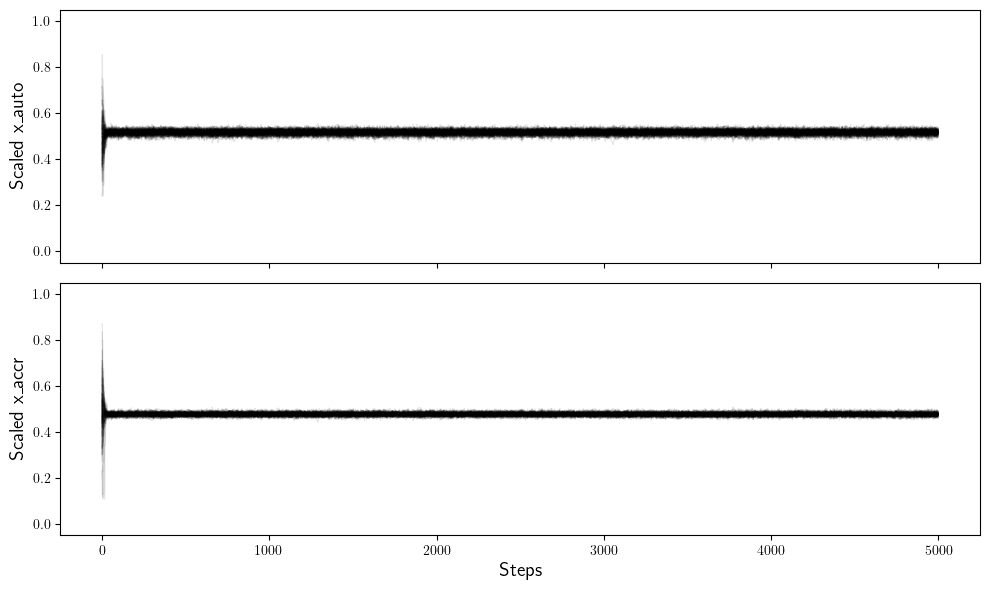

Posterior chains saved to 'posterior_chain_Radiation_Plus_LWP_PRECL_WROF_5PercErr_VarCov_nothin_flat.npy' and 'posterior_chain_Radiation_Plus_LWP_PRECL_WROF_5PercErr_VarCov_nothin_full.npy' 
Radiation_Plus_LWP_PRECL_WROF
--- Calculating Correlation Matrix for: ['OLR_UPWELL_PD', 'OSR_UPWELL_PD', 'LWP_PD', 'PRECL_PD', 'WROF_PD'] ---
Correlation Matrix (R) to be used:
 [[ 1.         -0.98770099 -0.90228268  0.522994    0.74351496]
 [-0.98770099  1.          0.94932811 -0.61873247 -0.82941388]
 [-0.90228268  0.94932811  1.         -0.68645523 -0.94339278]
 [ 0.522994   -0.61873247 -0.68645523  1.          0.7999927 ]
 [ 0.74351496 -0.82941388 -0.94339278  0.7999927   1.        ]]

--- Preparing for MCMC Experiment: Radiation_Plus_LWP_PRECL_WROF_20PercErr_VarCov ---
  - Constraint: OLR_UPWELL_PD, Obs=241.03, Err=2.00
  - Constraint: OSR_UPWELL_PD, Obs=97.90, Err=2.00
  - Constraint: LWP_PD, Obs=78.19, Err=15.64
  - Constraint: PRECL_PD, Obs=0.01, Err=0.00
  - Constraint: WROF_PD, Obs=0.62, 

  0%|          | 0/5000 [00:00<?, ?it/s]/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
  0%|          | 2/5000 [00:00<05:51, 14.24it/s]/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [04:49<00:00, 17.24it/s]



--- MCMC Run Complete! ---


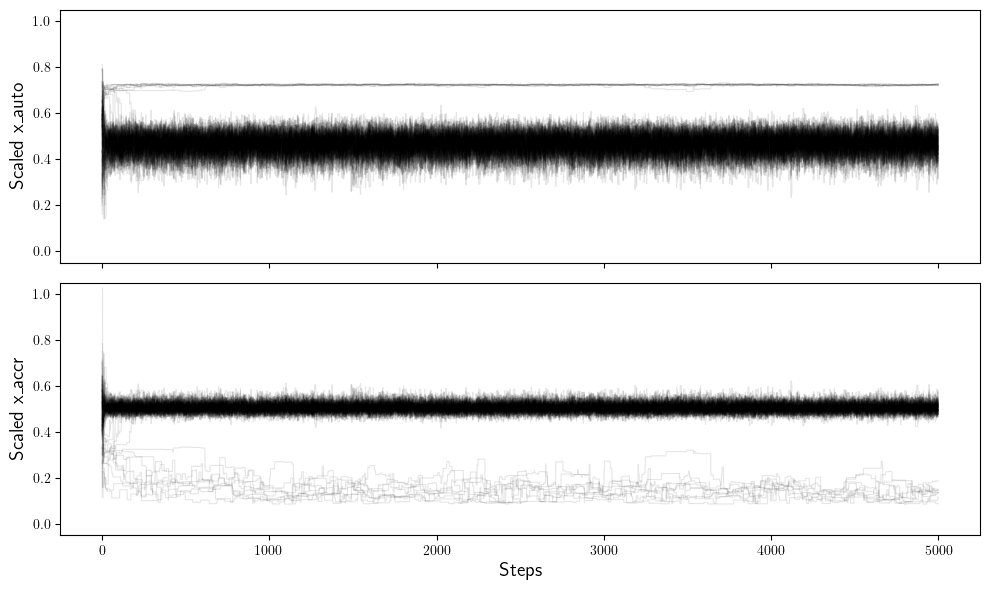

Posterior chains saved to 'posterior_chain_Radiation_Plus_LWP_PRECL_WROF_20PercErr_VarCov_nothin_flat.npy' and 'posterior_chain_Radiation_Plus_LWP_PRECL_WROF_20PercErr_VarCov_nothin_full.npy' 
Radiation_Plus_LWP_PRECL_WROF
--- Calculating Correlation Matrix for: ['OLR_UPWELL_PD', 'OSR_UPWELL_PD', 'LWP_PD', 'PRECL_PD', 'WROF_PD'] ---
Correlation Matrix (R) to be used:
 [[ 1.         -0.98770099 -0.90228268  0.522994    0.74351496]
 [-0.98770099  1.          0.94932811 -0.61873247 -0.82941388]
 [-0.90228268  0.94932811  1.         -0.68645523 -0.94339278]
 [ 0.522994   -0.61873247 -0.68645523  1.          0.7999927 ]
 [ 0.74351496 -0.82941388 -0.94339278  0.7999927   1.        ]]

--- Preparing for MCMC Experiment: Radiation_Plus_LWP_PRECL_WROF_50PercErr_VarCov ---
  - Constraint: OLR_UPWELL_PD, Obs=241.03, Err=2.00
  - Constraint: OSR_UPWELL_PD, Obs=97.90, Err=2.00
  - Constraint: LWP_PD, Obs=78.19, Err=39.10
  - Constraint: PRECL_PD, Obs=0.01, Err=0.00
  - Constraint: WROF_PD, Obs=0.62

  0%|          | 0/5000 [00:00<?, ?it/s]/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [04:29<00:00, 18.58it/s]



--- MCMC Run Complete! ---


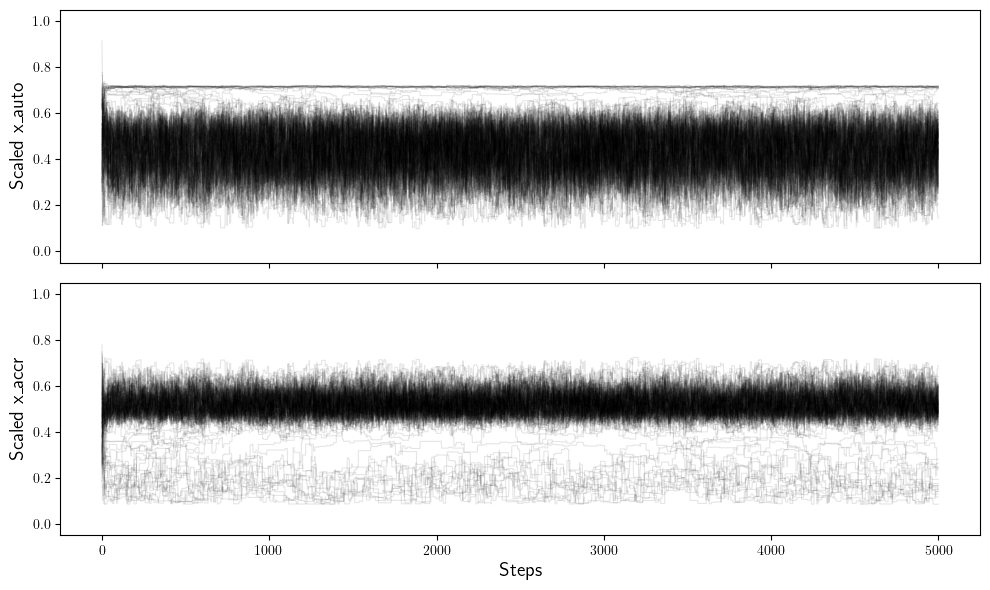

Posterior chains saved to 'posterior_chain_Radiation_Plus_LWP_PRECL_WROF_50PercErr_VarCov_nothin_flat.npy' and 'posterior_chain_Radiation_Plus_LWP_PRECL_WROF_50PercErr_VarCov_nothin_full.npy' 


In [21]:

obs_error_fractions = [0.05,0.2,0.5]
experiment_names = ['Radiation_Plus_LWP',\
                    'Radiation_Plus_LWP_ProcessRates',\
                    'Radiation_Plus_LWP_PRECL',\
                    'Radiation_Plus_LWP_ProcessRates',\
                    'Radiation_Plus_LWP_ProxyRates',\
                    'Radiation_Plus_LWP_PRECL_WROF',\
                   ]
experiment_names = experiment_names[5:]

for experiment_name_base in experiment_names:
    for obs_error_fraction in obs_error_fractions:
        print(experiment_name_base)
        
        rad_vars = ['OLR_UPWELL_PD','OSR_UPWELL_PD']
        cloud_vars = ['LWP_PD']
        proc_vars = ['AUTOCONV_PD','ACCRETN_PD']
        prox_vars = ['PRECL_PD','WROF_PD','PAF_PD']
        
        #experiment_name_base = 'Radiation_Only'
        #experiment_name_base = 'Radiation_Plus_LWP'
        #experiment_name_base = 'Radiation_Plus_LWP_ProcessRates'
        #experiment_name_base = 'Radiation_Plus_LWP_PRECL'
        #experiment_name_base = 'Radiation_Plus_LWP_ProxyRates'
        
        
        if experiment_name_base == 'Radiation_Only':
            constraint_vars = rad_vars
        elif experiment_name_base == 'Radiation_Plus_LWP':
            constraint_vars = rad_vars + cloud_vars
        elif experiment_name_base == 'Radiation_Plus_LWP_ProcessRates':
            constraint_vars = rad_vars + cloud_vars + proc_vars
        elif experiment_name_base == 'Radiation_Plus_LWP_ProxyRates':
            constraint_vars = rad_vars + cloud_vars + prox_vars
        elif experiment_name_base == 'Radiation_Plus_LWP_PRECL':
            constraint_vars = rad_vars + cloud_vars + ['PRECL_PD']
        elif experiment_name_base == 'Radiation_Plus_LWP_PRECL_WROF':
            constraint_vars = rad_vars + cloud_vars + ['PRECL_PD','WROF_PD']        
        
        if experiment_name_base != 'Radiation_Only':
            experiment_name = experiment_name_base+'_'+str(int(obs_error_fraction*100.))+'PercErr'
        else:
            experiment_name = experiment_name_base
        
        if use_correlations:
            experiment_name = experiment_name+'_VarCov'
        else:
            experiment_name = experiment_name+'_NoVarCov'
        
        variables_for_cov = constraint_vars # NOTE!: If we don't want variables to Co-Vary, then this needs to be changed to separate out variables used only for correlation vs. all constraint vars
        
        if run_mcmc:
            emulators_dir = f'./emulators_production'
            
            # --- 1. Compute the CORRELATION Matrix (R) for the correlated group ---
            R = None # Initialize R as None
            if variables_for_cov:
                print(f"--- Calculating Correlation Matrix for: {variables_for_cov} ---")
                outputs_train = df_dense_priors[variables_for_cov].to_numpy()
                R = np.corrcoef(outputs_train, rowvar=False)
        
                if not use_correlations:
                    print(">>> 'use_correlations' is False. Forcing independent calculation with identity matrix. <<<")
                    R = np.identity(R.shape[0])
                
            print("Correlation Matrix (R) to be used:\n", R)
        
            # --- 2. Load Emulators and Prepare All Observations ---
            emulators_to_use = {}
            transformations_to_use = {}
            observations_to_use = {}
            errors_to_use = {}
            print(f"\n--- Preparing for MCMC Experiment: {experiment_name} ---")
            for var_name in constraint_vars:
                emulators_to_use[var_name] = joblib.load(f'./{emulators_dir}/gp_production_{var_name}.joblib')
                transformations = joblib.load(f'{emulators_dir}/production_transforms.joblib')
                transformations_to_use[var_name] = transformations[var_name]
                
                if var_name in rad_vars:
                    obs_value = df_cntl[var_name].iloc[0]
                else: # Assumes all non-radiation vars are cloud vars
                    obs_value = df_cntl[var_name+'_regime2'].iloc[0]
                observations_to_use[var_name] = obs_value
                
        
                if var_name == 'OLR_UPWELL_PD':
                    errors_to_use[var_name] = 2.
                elif var_name == 'OSR_UPWELL_PD':
                    errors_to_use[var_name] = 2.
                else:
                    if transformations_to_use[var_name] == 'log':
                        errors_to_use[var_name] = obs_error_fraction
                    else:
                        errors_to_use[var_name] = obs_error_fraction * abs(obs_value)
                        
                if transformations_to_use[var_name] != 'log':     
                    print(f"  - Constraint: {var_name}, Obs={obs_value:.2f}, Err={errors_to_use[var_name]:.2f}")
                else:
                    print(f"  - Constraint: {var_name}, Obs={np.log(obs_value):.2f}, Err={errors_to_use[var_name]:.2f}")
        
        
            # --- 3. Structure Data for Correlated Group ---
            correlated_group_data = None
            if variables_for_cov:
                correlated_group_data = {
                    'vars': variables_for_cov,
                    'emulators': {var: emulators_to_use[var] for var in variables_for_cov},
                    'obs': {var: observations_to_use[var] for var in variables_for_cov},
                    'errors': {var: errors_to_use[var] for var in variables_for_cov}
                }
        
        
            log_posterior_fn = make_log_posterior_fn_multi_cov(
                emulators=emulators_to_use,
                transform_types=transformations_to_use,
                observations=observations_to_use,
                errors=errors_to_use,
                correlated_group=correlated_group_data,
                R_matrix=R, # Pass the correlation matrix R (will be None if no correlated vars)
                include_emulator_uncertainty=include_emulator_uncertainty
            )
            
            # --- 5. Run the MCMC Sampler ---
            ndim = 2
            nwalkers = 100
            nsteps = 5000
            burn_in = int(0.2 * nsteps)
            thin = 15 if thin_bool else 1
        
        
            # Bounds in regular space
            valid_lower_log = np.log10([2**-8., 2**-8.])  # Lower bounds in log10 space
            valid_upper_log = np.log10([2**8., 2**8.])    # Upper bounds in log10 space
            
            # Ensure the input is reshaped for the scaler (expecting 2D input: (n_samples, n_features))
            valid_lower_scaled = global_x_scaler.transform(valid_lower_log.reshape(1, -1))[0]  # Scaled lower bound
            valid_upper_scaled = global_x_scaler.transform(valid_upper_log.reshape(1, -1))[0]  # Scaled upper bound
            
            # Set mean and standard deviation for the normal distribution
            mean = (valid_lower_scaled + valid_upper_scaled) / 2  # Center of the bounds
            std_dev = np.abs(valid_upper_scaled - valid_lower_scaled) / 6  # Spread (approx 99.7%)
            
            # Generate samples and clip them to stay within bounds
            initial_state = np.random.normal(loc=mean, scale=std_dev, size=(nwalkers, ndim))    
                
            sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_fn, moves=emcee.moves.StretchMove(3.0))
            print(f"\n--- Running MCMC for experiment: {experiment_name} ---")
            sampler.run_mcmc(initial_state, nsteps, progress=True)
            print("\n--- MCMC Run Complete! ---")
        
            # Assuming plot_trace is defined elsewhere
            plot_trace(sampler, nwalkers, nsteps, ndim, experiment_name)
            
            # --- 6. Save and Plot Results ---
            chain_flat = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
            chain_full = sampler.get_chain()
            output_filename = f'posterior_chain_{experiment_name}_{"thin" if thin_bool else "nothin"}_flat.npy'
            np.save('./mcmc_chains/' + output_filename, chain_flat)
            output_filename_full = f'posterior_chain_{experiment_name}_{"thin" if thin_bool else "nothin"}_full.npy'
            np.save('./mcmc_chains/' + output_filename_full, chain_full)
        
            # Save the data required for the Trace Plot
            log_prob_full = sampler.get_log_prob()
            acceptance_fractions = sampler.acceptance_fraction
            trace_data_filename = f'trace_data_{experiment_name}.npz'
            np.savez_compressed('./mcmc_chains/'+trace_data_filename,
                                chain=chain_full,
                                log_prob=log_prob_full,
                                acceptance_fraction=acceptance_fractions)
        
            print(f"Posterior chains saved to '{output_filename}' and '{output_filename_full}' ")
            


# Read in trace data and make trace plots


--- Diagnostics for Radiation_Only_VarCov ---
Mean acceptance fraction: 0.387
Std dev of acceptance fractions: 0.033
Min acceptance fraction: 0.295
Max acceptance fraction: 0.449


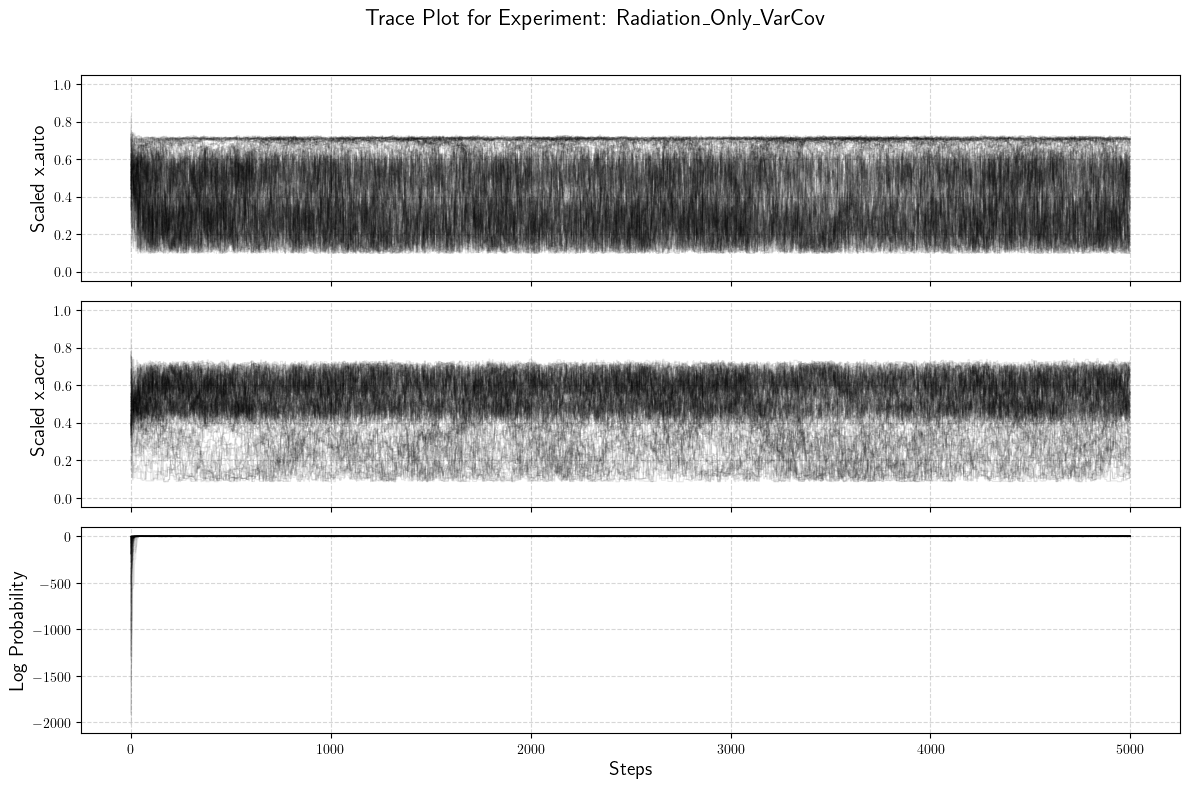


--- Diagnostics for Radiation_Plus_LWP_20PercErr_VarCov ---
Mean acceptance fraction: 0.648
Std dev of acceptance fractions: 0.090
Min acceptance fraction: 0.040
Max acceptance fraction: 0.692


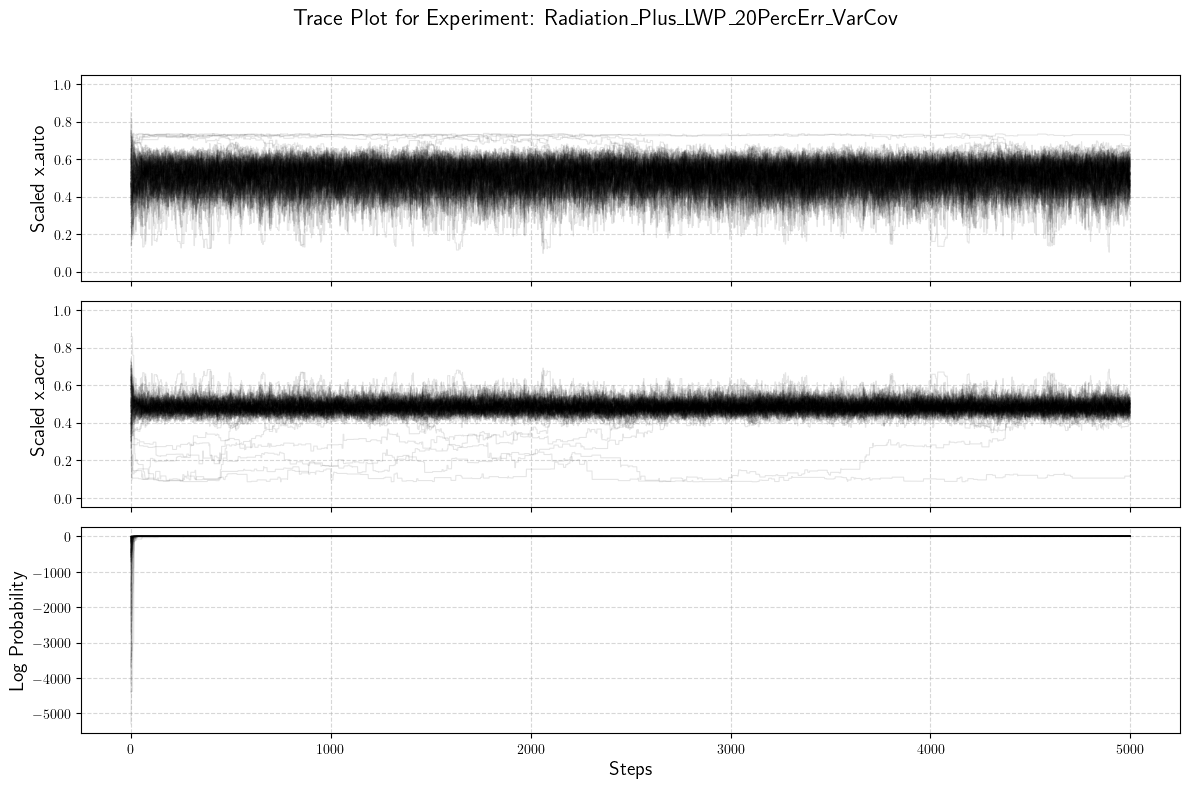


--- Diagnostics for Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov ---
Mean acceptance fraction: 0.698
Std dev of acceptance fractions: 0.067
Min acceptance fraction: 0.042
Max acceptance fraction: 0.722


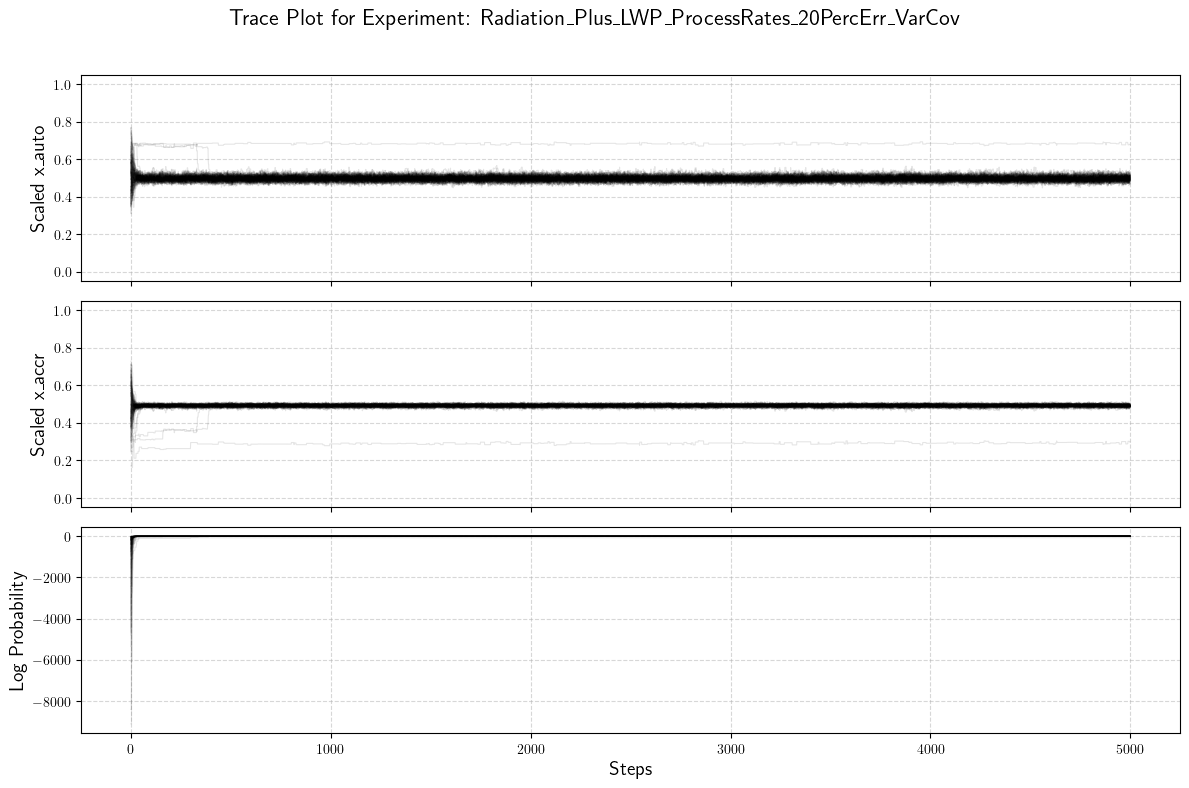

In [8]:
#experiment_name = 'Radiation_Only_VarCov'
experiment_name_exp1 = 'Radiation_Only_VarCov'
experiment_name_exp2 = 'Radiation_Plus_LWP_20PercErr_VarCov'
experiment_name_exp3 = 'Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov'

trace_data_filename_exp1 = f'./mcmc_chains/trace_data_{experiment_name_exp1}.npz'
data_exp1 = np.load(trace_data_filename_exp1)
chain_full_exp1 = data_exp1['chain']
log_prob_full_exp1 = data_exp1['log_prob']
acceptance_fractions_exp1 = data_exp1['acceptance_fraction']
plot_trace_from_data(chain_full_exp1, log_prob_full_exp1, acceptance_fractions_exp1, experiment_name_exp1)

trace_data_filename_exp2 = f'./mcmc_chains/trace_data_{experiment_name_exp2}.npz'
data_exp2 = np.load(trace_data_filename_exp2)
chain_full_exp2 = data_exp2['chain']
log_prob_full_exp2 = data_exp2['log_prob']
acceptance_fractions_exp2 = data_exp2['acceptance_fraction']
plot_trace_from_data(chain_full_exp2, log_prob_full_exp2, acceptance_fractions_exp2, experiment_name_exp2)

trace_data_filename_exp3 = f'./mcmc_chains/trace_data_{experiment_name_exp3}.npz'
data_exp3 = np.load(trace_data_filename_exp3)
chain_full_exp3 = data_exp3['chain']
log_prob_full_exp3 = data_exp3['log_prob']
acceptance_fractions_exp3 = data_exp3['acceptance_fraction']
plot_trace_from_data(chain_full_exp3, log_prob_full_exp3, acceptance_fractions_exp3, experiment_name_exp3)

In [28]:
experiment_name_exp1 = 'Radiation_Only_VarCov'
experiment_name_exp2 = 'Radiation_Plus_LWP_20PercErr_VarCov'
experiment_name_exp3 = 'Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov'

trace_data_filename_exp1 = f'./mcmc_chains/trace_data_{experiment_name_exp1}.npz'
trace_data_filename_exp2 = f'./mcmc_chains/trace_data_{experiment_name_exp2}.npz'
trace_data_filename_exp3 = f'./mcmc_chains/trace_data_{experiment_name_exp3}.npz'

file_names = [trace_data_filename_exp1,trace_data_filename_exp2,trace_data_filename_exp3]


# --- 2. Create the Figure (Now with an extra row for log_prob) ---
fig, axes = plt.subplots(nrows=3,ncols=3, figsize=(18,8),constrained_layout=True)
Fontsize = 18

# First 'axes' index is # of rows

axes_flat = np.ndarray.flatten(axes)
for ax in axes_flat:
    ax.tick_params(labelsize=Fontsize*0.8)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlim(0,5000)

axes_left = axes[:,0]
axes_bot = axes[-1,:]
axes_top = axes[0,:]
axes_mid = axes[1,:]


for ax in axes_top:
    ax.set_ylim(0,1)
for ax in axes_mid:
    ax.set_ylim(0,1)
    
axes[0,0].set_ylabel('Scaled x_auto',fontsize=Fontsize)
axes[1,0].set_ylabel('Scaled x_accr',fontsize=Fontsize)
axes[2,0].set_ylabel('Log Probability',fontsize=Fontsize)

for ax in axes_bot:
    ax.set_xlabel('Steps',fontsize=Fontsize)
    

colors = ['k','tomato','royalblue']
for i,file_name in enumerate(file_names):

    tmp_axes = axes[:,i]

    
    data = np.load(file_name)
    chain_data = data['chain']
    log_prob_data = data['log_prob']
    acceptance_fraction_data = data['acceptance_fraction']

    # --- 1. Extract Dimensions from the Input Data ---
    nsteps, nwalkers, ndim = chain_data.shape
    invars = ['x_auto', 'x_accr'] # Assuming ndim is always 2

    # --- 3. Plot the Parameter Traces ---
    for j in range(ndim):
        ax = tmp_axes[j]
        for walker in range(nwalkers):
            ax.plot(chain_data[:, walker, j], alpha=0.1, lw=1, c=colors[i])

    # --- 4. Plot the Log Probability Trace (Highly Recommended) ---
    ax = tmp_axes[ndim] # The last subplot
    for walker in range(nwalkers):
        ax.plot(log_prob_data[:, walker], alpha=0.25, lw=1, c=colors[i])


for ax in axes_bot:
    ax.set_xscale('log')
    ax.set_xlim(1,5000)

if False:
    for ax in axes_top:
        ax.set_xscale('log')
        ax.set_xlim(1,5000)
    
    for ax in axes_mid:
        ax.set_xscale('log')
        ax.set_xlim(1,5000)

if True:
    for ax in axes_top:
        ax.set_xlim(-100,5000)
    for ax in axes_mid:
        ax.set_xlim(-100,5000)
    
axes_top[0].set_title(r'\textbf{Radiation_Baseline}',fontsize=Fontsize*1.25,c='k')
axes_top[1].set_title(r'\textbf{+ $\mathcal{L}$}',fontsize=Fontsize*1.25,c='k')
axes_top[2].set_title(r'\textbf{+ $\mathcal{L}$ + Proc. Rates}',fontsize=Fontsize*1.25,c='k')


plt.suptitle(r'\textbf{20\% Observational Error}',fontsize=Fontsize*1.5)

for ax in axes_flat:
    ax.axvline(1000,c='magenta',lw=2,ls='dashed',label='Burn-in Point')

axes_flat[0].legend(loc='upper right',framealpha=False,fontsize=Fontsize*0.8,bbox_to_anchor=(1.025,1.05))

panel_labels = string.ascii_lowercase
for i,ax in enumerate(axes_flat):
    if i <= 5:
        ax.text(0.01,0.99,rf'({panel_labels[i]})',transform=ax.transAxes,fontsize=Fontsize*1.5,va='top',ha='left')
    else:
        ax.text(0.99,0.99,rf'({panel_labels[i]})',transform=ax.transAxes,fontsize=Fontsize*1.5,va='top',ha='right')


# --- 6. Save and Show ---
save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'trace_plots_20PercObsErr.png'
plt.savefig(save_path + file_name, dpi=300)
#plt.show()
plt.close()
print('done')

done


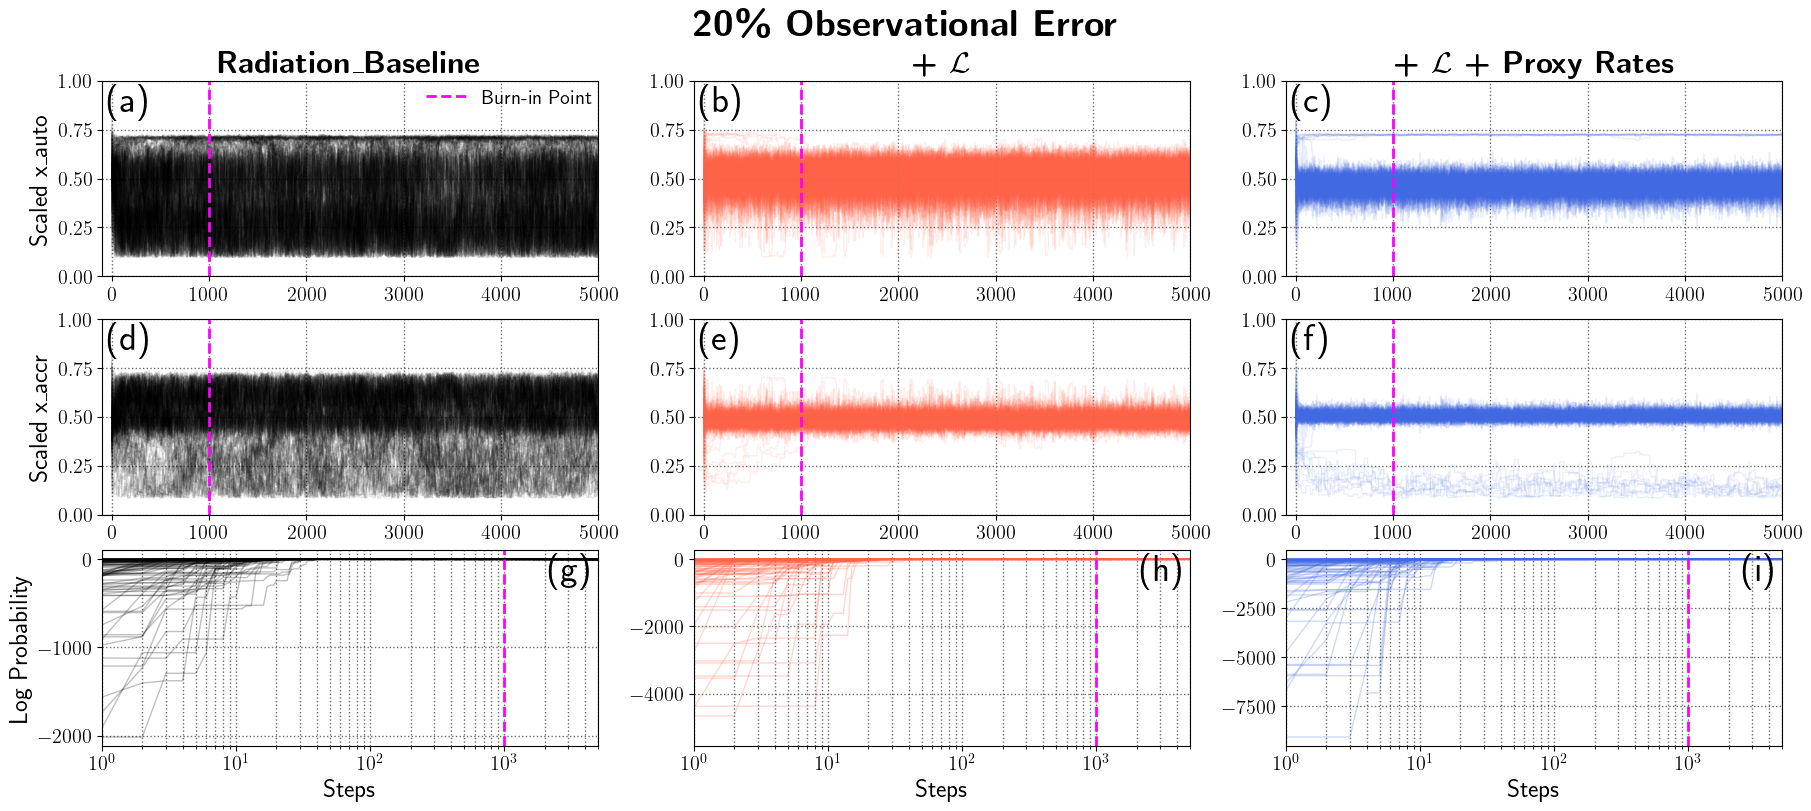

done


In [23]:
experiment_name_exp1 = 'Radiation_Only_VarCov'
experiment_name_exp2 = 'Radiation_Plus_LWP_20PercErr_VarCov'
#experiment_name_exp3 = 'Radiation_Plus_LWP_ProxyRates_20PercErr_VarCov'
experiment_name_exp3 = 'Radiation_Plus_LWP_PRECL_WROF_20PercErr_VarCov'

trace_data_filename_exp1 = f'./mcmc_chains/trace_data_{experiment_name_exp1}.npz'
trace_data_filename_exp2 = f'./mcmc_chains/trace_data_{experiment_name_exp2}.npz'
trace_data_filename_exp3 = f'./mcmc_chains/trace_data_{experiment_name_exp3}.npz'

file_names = [trace_data_filename_exp1,trace_data_filename_exp2,trace_data_filename_exp3]


# --- 2. Create the Figure (Now with an extra row for log_prob) ---
fig, axes = plt.subplots(nrows=3,ncols=3, figsize=(18,8),constrained_layout=True)
Fontsize = 18

# First 'axes' index is # of rows

axes_flat = np.ndarray.flatten(axes)
for ax in axes_flat:
    ax.tick_params(labelsize=Fontsize*0.8)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_xlim(0,5000)

axes_left = axes[:,0]
axes_bot = axes[-1,:]
axes_top = axes[0,:]
axes_mid = axes[1,:]


for ax in axes_top:
    ax.set_ylim(0,1)
for ax in axes_mid:
    ax.set_ylim(0,1)
    
axes[0,0].set_ylabel('Scaled x_auto',fontsize=Fontsize)
axes[1,0].set_ylabel('Scaled x_accr',fontsize=Fontsize)
axes[2,0].set_ylabel('Log Probability',fontsize=Fontsize)

for ax in axes_bot:
    ax.set_xlabel('Steps',fontsize=Fontsize)
    

colors = ['k','tomato','royalblue']
for i,file_name in enumerate(file_names):

    tmp_axes = axes[:,i]

    
    data = np.load(file_name)
    chain_data = data['chain']
    log_prob_data = data['log_prob']
    acceptance_fraction_data = data['acceptance_fraction']

    # --- 1. Extract Dimensions from the Input Data ---
    nsteps, nwalkers, ndim = chain_data.shape
    invars = ['x_auto', 'x_accr'] # Assuming ndim is always 2

    # --- 3. Plot the Parameter Traces ---
    for j in range(ndim):
        ax = tmp_axes[j]
        for walker in range(nwalkers):
            ax.plot(chain_data[:, walker, j], alpha=0.1, lw=1, c=colors[i])

    # --- 4. Plot the Log Probability Trace (Highly Recommended) ---
    ax = tmp_axes[ndim] # The last subplot
    for walker in range(nwalkers):
        ax.plot(log_prob_data[:, walker], alpha=0.25, lw=1, c=colors[i])


for ax in axes_bot:
    ax.set_xscale('log')
    ax.set_xlim(1,5000)

if False:
    for ax in axes_top:
        ax.set_xscale('log')
        ax.set_xlim(1,5000)
    
    for ax in axes_mid:
        ax.set_xscale('log')
        ax.set_xlim(1,5000)

if True:
    for ax in axes_top:
        ax.set_xlim(-100,5000)
    for ax in axes_mid:
        ax.set_xlim(-100,5000)
    
axes_top[0].set_title(r'\textbf{Radiation_Baseline}',fontsize=Fontsize*1.25,c='k')
axes_top[1].set_title(r'\textbf{+ $\mathcal{L}$}',fontsize=Fontsize*1.25,c='k')
axes_top[2].set_title(r'\textbf{+ $\mathcal{L}$ + Proxy Rates}',fontsize=Fontsize*1.25,c='k')


plt.suptitle(r'\textbf{20\% Observational Error}',fontsize=Fontsize*1.5)

for ax in axes_flat:
    ax.axvline(1000,c='magenta',lw=2,ls='dashed',label='Burn-in Point')

axes_flat[0].legend(loc='upper right',framealpha=False,fontsize=Fontsize*0.8,bbox_to_anchor=(1.025,1.05))

panel_labels = string.ascii_lowercase
for i,ax in enumerate(axes_flat):
    if i <= 5:
        ax.text(0.01,0.99,rf'({panel_labels[i]})',transform=ax.transAxes,fontsize=Fontsize*1.5,va='top',ha='left')
    else:
        ax.text(0.99,0.99,rf'({panel_labels[i]})',transform=ax.transAxes,fontsize=Fontsize*1.5,va='top',ha='right')


# --- 6. Save and Show ---
save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'trace_plots_20PercObsErr_proxy.png'
#plt.savefig(save_path + file_name, dpi=300)
plt.show()
plt.close()
print('done')

# Visualize emulator uncertainty as a function of x_auto,x_accr

In [142]:
global_x_scaler = joblib.load('./emulators_production/global_x_scaler.joblib')
emulators_dir = './emulators_production'
transforms = joblib.load('./emulators_production/production_transforms.joblib')

pre_path = '/glade/u/home/mckenna/work/ppe_pre/'
filename = 'e3sm_lhs_samples.csv'
df_pre = pd.read_csv(pre_path+filename)

gp_1 = joblib.load(f'./{emulators_dir}/gp_production_LWP_PD.joblib')
gp_2 = joblib.load(f'./{emulators_dir}/gp_production_LWP_adj.joblib')
gp_3 = joblib.load(f'./{emulators_dir}/gp_production_AUTOCONV_PD.joblib')
gp_4 = joblib.load(f'./{emulators_dir}/gp_production_ERF_ACI.joblib')

gps = [gp_1,gp_2,gp_3,gp_4]
var_names = ['LWP_PD', 'LWP_adj', 'AUTOCONV_PD', 'ERF_ACI']
# --- Observation and error settings ---
obs = [df_cntl['LWP_PD_regime2'].iloc[0], df_cntl['LWP_adj_regime2'].iloc[0], df_cntl['AUTOCONV_PD_regime2'].iloc[0],df_cntl['ERF_ACI'].iloc[0]] # physical observation (scalar)
obs_error_fraction = 0.2              # e.g., 5% relative error
eps = 1e-20
n_obs = len(obs)


n_points_plot = 100  # Resolution in x_auto and x_accr dimensions
x_auto_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_accr_scaled = np.linspace(0.01, 0.99, n_points_plot)
x_auto_grid, x_accr_grid = np.meshgrid(x_auto_scaled, x_accr_scaled)

gp_err = np.empty((n_obs, n_points_plot, n_points_plot))


# Loop over the 2D grid
for i in range(n_points_plot):
    for j in range(n_points_plot):
        theta_point = np.array([[x_auto_grid[i, j], x_accr_grid[i, j]]]) # Shape must be (1, 2)
        
        # Loop over each emulator
        for k in range(n_obs):
            # Directly get the standard deviation from the emulator.
            # This is the raw uncertainty, which is what we want to plot.
            _, std_proc = gps[k].predict(theta_point, return_std=True)
            gp_err[k, i, j] = std_proc[0]

# Flatten meshgrids to construct proper input for inverse_transform
x_auto_flat = x_auto_grid.ravel()  # Flatten the meshgrid for x_auto
x_accr_flat = x_accr_grid.ravel()  # Flatten the meshgrid for x_accr

# Combine flattened arrays into 2D input for inverse_transform
scaled_flat = np.stack((x_auto_flat, x_accr_flat), axis=-1)  # Shape: (n_points_plot**2, 2)

# Undo scaling in log10 space (get log10 of physical values)
log10_physical_flat = global_x_scaler.inverse_transform(scaled_flat)  # Shape: (n_points_plot**2, 2)

# Separate the transformed values for x_auto and x_accr
x_auto_log10_flat = log10_physical_flat[:, 0]  # Log10 of x_auto
x_accr_log10_flat = log10_physical_flat[:, 1]  # Log10 of x_accr

# Convert log10 values to physical values (exponentiation)
x_auto_physical_flat = 10.0 ** x_auto_log10_flat
x_accr_physical_flat = 10.0 ** x_accr_log10_flat

# Reshape back to 2D arrays for plotting
x_auto_physical = x_auto_physical_flat.reshape(x_auto_grid.shape)  # Shape: (n_points_plot, n_points_plot)
x_accr_physical = x_accr_physical_flat.reshape(x_accr_grid.shape)  # Shape: (n_points_plot, n_points_plot)


fig, xaxes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = np.ndarray.flatten(xaxes)
Fontsize = 16

# This will hold the handles for the colorbars
cbars = []

for k, ax in enumerate(axes):
    var_name = var_names[k]
    transform_type = transforms.get(var_name, 'linear')
    
    # Plot the uncertainty contour
    c = ax.contourf(x_auto_physical, x_accr_physical, gp_err[k,:,:], levels=30, cmap='magma')
    
    # Add a colorbar
    cbar = fig.colorbar(c, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=Fontsize - 2)
    cbars.append(cbar)
    
    # --- Set the colorbar label correctly based on transform type ---
    if transform_type == 'log':
        cbar.ax.set_ylabel(r'GP $\sigma$ (log-space)', fontsize=Fontsize)
    else:
        cbar.ax.set_ylabel(r'GP $\sigma$', fontsize=Fontsize)
        
    # --- Set titles and scales (unchanged) ---
    ax.set_xlabel("x_auto (Autoconversion)", fontsize=Fontsize)
    ax.set_ylabel("x_accr (Accretion)", fontsize=Fontsize)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize - 2)
    
# --- Set titles for each subplot ---
axes[0].set_title(r'\textbf{$\mathcal{L}$}', fontsize=Fontsize*2.)
axes[1].set_title(r'\textbf{$\mathcal{L}_{\mathrm{adj}}$}', fontsize=Fontsize*2.)
axes[2].set_title(r'\textbf{AUTOCONV}', fontsize=Fontsize*2.)
axes[3].set_title(r'\textbf{ERF$_{\mathrm{ACI}}$}', fontsize=Fontsize*2.)

xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

scatter_handles, scatter_labels = [], []

# Physical bounds for the valid region
valid_lower = 2**-8   # Lower bound in physical units: 0.00390625
valid_upper = 2**8    # Upper bound in physical units: 256

for i,ax in enumerate(axes):
    ax.scatter(
        df_pre['Autoconversion Factor'][0:50],
        df_pre['Accretion Factor'][0:50],
        c='teal',
        edgecolor='k',
        alpha=0.8,
        s=50,
        label='Latin Square Samples (PPE)'
    )


    # Draw the contour box
    ax.contour(
        x_auto_physical, x_accr_physical,
        ((x_auto_physical >= valid_lower) & (x_auto_physical <= valid_upper)) *
        ((x_accr_physical >= valid_lower) & (x_accr_physical <= valid_upper)),
        levels=[0.5],
        colors="cyan", linestyles="dashed", linewidths=2
    )

    # On the first iteration, grab the handle from the scatter plot
    if i == 0:
        scatter_handles, scatter_labels = ax.get_legend_handles_labels()
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    

# 1. Create a proxy artist for the cyan dashed line
contour_proxy = mlines.Line2D([], [], color='cyan', linestyle='dashed', 
                              linewidth=2, label="Valid Region (2$^{-8}$ to 2$^{8}$)")

# 2. Combine the handles and labels from both elements
all_handles = scatter_handles + [contour_proxy]
all_labels = scatter_labels + [contour_proxy.get_label()]

# 3. Create the legend using the combined lists
lgnd = axes[0].legend(handles=all_handles, labels=all_labels,
                      fontsize=Fontsize*0.8, loc='upper center', 
                      #bbox_to_anchor=(1.25, 1.125), framealpha=True)
                      bbox_to_anchor=(1.25, -0.05), framealpha=True)

# --- END: NEW LEGEND CREATION ---

lgnd.set_in_layout(False)


panel_labels = string.ascii_lowercase
for i,ax in enumerate(axes):
    #ax.text(0.01,1.1,rf'({panel_labels[i]})',transform=ax.transAxes,fontsize=Fontsize*1.5,va='top',ha='left')
    ax.text(0.01,0.99,rf'\textbf{{({panel_labels[i]})}}',transform=ax.transAxes,fontsize=Fontsize*1.75,va='top',ha='left',c='white')

# --- 6. Save and Show ---
save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'GP_uncertainty_visualization.png'
plt.savefig(save_path + file_name, dpi=300)
#plt.show()
plt.close()
print('done')

done


# Propagate posterior input parameters through emulators for constrained output variables

In [27]:
if run_prop:

    thin_bool = False
    if thin_bool:
        thin_str = 'thin'
    else:
        thin_str = 'nothin'
        
# Whether or not to propagate emulator error back through constrained distributions
post_GPerr_prop_bool = False
    
obs_error_fractions = [0.05,0.2,0.5]
experiment_name_bases = ['Radiation_Only',\
                    'Radiation_Plus_LWP',\
                    'Radiation_Plus_LWP_ProcessRates',\
                    'Radiation_Plus_LWP_PRECL',\
                    'Radiation_Plus_LWP_ProcessRates',\
                    'Radiation_Plus_LWP_ProxyRates',\
                    'Radiation_Plus_LWP_PRECL_WROF']


experiment_names = []
experiment_names.append(experiment_name_bases[0]+'_VarCov_'+thin_str)

experiment_names = []
experiment_name_bases = experiment_name_bases[6:]

for experiment_name_base in experiment_name_bases:
    for obs_error_fraction in obs_error_fractions:
        experiment_names.append(experiment_name_base+'_'+str(int(obs_error_fraction*1.e2))+'PercErr_VarCov_'+thin_str)


vars_to_propagate = ['OSR_UPWELL_PD','OLR_UPWELL_PD','RESTOM_PD','ERF_ACI','LWP_PD','LWP_adj', 'PRECL_PD','WROF_PD', 'PAF_PD',   'AUTOCONV_PD', 'ACCRETN_PD', ]

bounds_map = {
    # Variables with only a lower bound of 0
    'PRECL_PD': (0, np.inf),
    'LWP_PD':   (0, np.inf),
    'AUTOCONV_PD':  (0, np.inf),
    'ACCRETN_PD':  (0, np.inf),
    'WROF_PD':  (0, 1),
    'PAF_PD':  (0, 1),
}

for experiment_name in experiment_names:
    print('-'*50)
    print('-'*3,experiment_name,'-'*3)
    print('-'*50)
    chain_log_scaled = np.load(f'./mcmc_chains/posterior_chain_{experiment_name}_flat.npy')
    posterior_outputs = {}
    print("--- Propagating Posteriors ---")
    transforms = joblib.load(f'./emulators_production/production_transforms.joblib')

    for var in vars_to_propagate:
        try:
            emulator_path = f'./emulators_production/gp_production_{var}.joblib'
            emulator = joblib.load(emulator_path)
            transform_type = transforms[var]

            # --- Step 1: Predict in Processed (Emulator) Space ---
            post_pred_val, post_pred_std = emulator.predict(chain_log_scaled, return_std=True)

            # --- Step 2: Get Samples in Processed Space ---
            if post_GPerr_prop_bool:
                print(f"  - Sampling outputs for {var}")
                # For log-transformed variables, the physical bound (0, inf) corresponds to
                # an unbounded (-inf, inf) range in log-space. So we don't need to truncate them here.
                if transform_type == 'log':
                    processed_samples = np.random.normal(loc=post_pred_val, scale=post_pred_std)
                elif var in bounds_map:
                    # For *linear* variables that are bounded, use truncnorm
                    lower_bound, upper_bound = bounds_map[var]
                    # Ensure std_dev is not zero to avoid division errors
                    post_pred_std[post_pred_std == 0] = 1e-20
                    a = (lower_bound - post_pred_val) / post_pred_std
                    b = (upper_bound - post_pred_val) / post_pred_std
                    processed_samples = stats.truncnorm.rvs(a, b, loc=post_pred_val, scale=post_pred_std)
                else:
                    # For unbounded linear variables
                    processed_samples = np.random.normal(loc=post_pred_val, scale=post_pred_std)
            else:
                # Deterministic propagation: just use the mean prediction
                processed_samples = post_pred_val

            # --- Step 3: Transform Samples to Physical Space ---
            if transform_type == 'log':
                physical_samples = np.exp(processed_samples)
            else:
                physical_samples = processed_samples

            # --- Step 4: Apply Physical Bounds in Physical Space (Crucial Final Step) ---
            # This is a robust final check for both deterministic and stochastic paths.
            if var in bounds_map:
                lower_bound, upper_bound = bounds_map[var]
                # Using np.clip is a clean and effective way to enforce hard bounds.
                physical_samples = np.clip(physical_samples, lower_bound, upper_bound)
            
            # Save the final, correct physical samples
            posterior_outputs[var] = physical_samples
            print(f"  - Propagated {var}")
        
        except FileNotFoundError:
            print(f"  - WARNING: Emulator not found for {var} at {emulator_path}. Skipping.")
        except Exception as e:
            print(f"  - ERROR while propagating {var}: {e}. Skipping.")

    plot_data_dict = {'priors': {}, 'posteriors': {}}
    plot_data_dict['posteriors'] = posterior_outputs

    print("\n--- Packaging Priors into Dictionary---")
    all_vars = list(posterior_outputs.keys())
    
    for var in all_vars:
        if var in df_dense_priors.columns:
            plot_data_dict['priors'][var] = dense_priors[var]
            print(f"  - Saved prior for '{var}'")
        else:
            print(f"  - CRITICAL WARNING: Prior data for '{var}' not found in dense source. Skipping.")

    # --- Unscale Inputs ---
    log_scaler = joblib.load('./emulators_production/global_x_scaler.joblib')
    chain_log = log_scaler.inverse_transform(chain_log_scaled)
    chain_physical = 10**chain_log
    input_features = ['x_auto', 'x_accr']
    plot_data_dict['priors']['inputs'] = {}
    plot_data_dict['posteriors']['inputs'] = {}
    X_original = df_regime2[input_features].to_numpy()
    for i, feature in enumerate(input_features):
        plot_data_dict['priors']['inputs'][feature] = X_original[:, i]
        plot_data_dict['posteriors']['inputs'][feature] = chain_physical[:, i]

    # --- 5. Save the Final Dictionary ---
    if post_GPerr_prop_bool:
        post_GPerr_prop_str = 'withPostGPerrProp'
    else:
        post_GPerr_prop_str = 'withoutPostGPerrProp'
        
    dict_filename = f'./mcmc_prop/constrained_prop_{experiment_name}_{post_GPerr_prop_str}.pkl'
        
    with open(dict_filename, "wb") as file:
        pickle.dump(plot_data_dict, file)
    print(f"\nSelf-contained plotting data dictionary saved to '{dict_filename}'")
    
    #print(aaaaa)

--------------------------------------------------
--- Radiation_Plus_LWP_PRECL_WROF_5PercErr_VarCov_nothin ---
--------------------------------------------------
--- Propagating Posteriors ---
  - Propagated OSR_UPWELL_PD
  - Propagated OLR_UPWELL_PD
  - Propagated RESTOM_PD
  - Propagated ERF_ACI
  - Propagated LWP_PD
  - Propagated LWP_adj
  - Propagated PRECL_PD
  - Propagated WROF_PD
  - Propagated PAF_PD
  - Propagated AUTOCONV_PD
  - Propagated ACCRETN_PD

--- Packaging Priors into Dictionary---
  - Saved prior for 'OSR_UPWELL_PD'
  - Saved prior for 'OLR_UPWELL_PD'
  - Saved prior for 'RESTOM_PD'
  - Saved prior for 'ERF_ACI'
  - Saved prior for 'LWP_PD'
  - Saved prior for 'LWP_adj'
  - Saved prior for 'PRECL_PD'
  - Saved prior for 'WROF_PD'
  - Saved prior for 'PAF_PD'
  - Saved prior for 'AUTOCONV_PD'
  - Saved prior for 'ACCRETN_PD'

Self-contained plotting data dictionary saved to './mcmc_prop/constrained_prop_Radiation_Plus_LWP_PRECL_WROF_5PercErr_VarCov_nothin_withoutPo